In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense,LSTM,GRU
from tensorflow.keras.models import Sequential

In [9]:
# load the IMDB dataset

(X_train,y_train),(X_test,y_test) = imdb.load_data(num_words=10000)

# Pad sequences to have the same length
X_train = pad_sequences(X_train,maxlen=100)
X_test = pad_sequences(X_test,maxlen=100)

In [12]:
# Define the RNN model

model = Sequential()

model.add(Embedding(10000,32,input_shape=(100,))) # Embedding layer to convert words to vectors
model.add(SimpleRNN(5,return_sequences=True)) # RNN layer with 5 units

model.add(SimpleRNN(5)) # Another RNN layer with 5 units
model.add(Dense(1,activation='sigmoid')) # output layer for binary classification

model.summary()

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 100, 5)         │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,251 (1.22 MB)

 Trainable params: 320,251 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [14]:
history = model.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6935 - loss: 0.5756 - val_accuracy: 0.7616 - val_loss: 0.5138
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8343 - loss: 0.3922 - val_accuracy: 0.7936 - val_loss: 0.4849
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8842 - loss: 0.2931 - val_accuracy: 0.7908 - val_loss: 0.4824
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9088 - loss: 0.2379 - val_accuracy: 0.7884 - val_loss: 0.5092
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9301 - loss: 0.1934 - val_accuracy: 0.7776 - val_loss: 0.5830


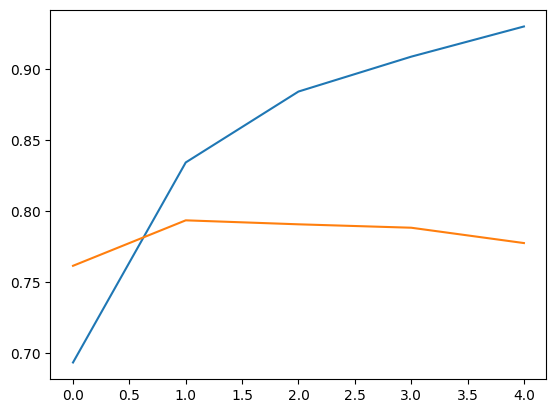

In [26]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'],label='validation_accuracy')

In [17]:
# Define the LSTM model
model2 = Sequential()

model2.add(Embedding(10000,32,input_shape=(100,)))
model2.add(LSTM(5,return_sequences=True))
model2.add(LSTM(5))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 5)         │           760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 5)              │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,986 (1.22 MB)

 Trainable params: 320,986 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [29]:
history2 = model2.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9750 - loss: 0.0886 - val_accuracy: 0.8236 - val_loss: 0.5523
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9805 - loss: 0.0701 - val_accuracy: 0.8258 - val_loss: 0.6216
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9815 - loss: 0.0649 - val_accuracy: 0.8192 - val_loss: 0.6267
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9884 - loss: 0.0473 - val_accuracy: 0.8242 - val_loss: 0.6673
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9887 - loss: 0.0441 - val_accuracy: 0.8210 - val_loss: 0.7538


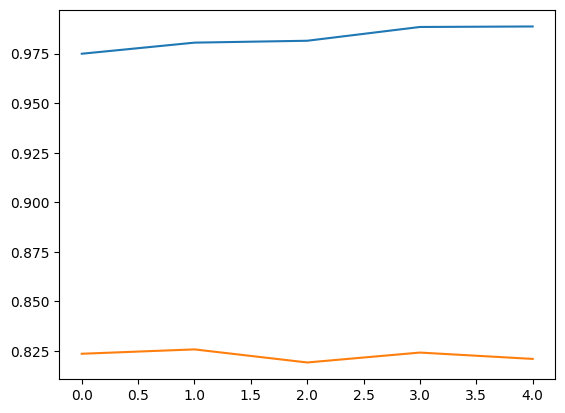

In [31]:
plt.plot(history2.history['accuracy'],label='accuracy')
plt.plot(history2.history['val_accuracy'],label='validation_accuracy')

In [33]:
# Define the GRU model
model3 = Sequential()

model3.add(Embedding(10000,32,input_shape=(100,)))
model3.add(GRU(5,return_sequences=True))
model3.add(GRU(5))
model3.add(Dense(1,activation='sigmoid'))

model3.summary()

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 100, 5)         │           585 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 5)              │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,771 (1.22 MB)

 Trainable params: 320,771 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model3.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [22]:
history3 = model3.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.7569 - loss: 0.4891 - val_accuracy: 0.8328 - val_loss: 0.3846
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.8859 - loss: 0.2917 - val_accuracy: 0.8452 - val_loss: 0.3613
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9197 - loss: 0.2201 - val_accuracy: 0.8466 - val_loss: 0.3688
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9440 - loss: 0.1667 - val_accuracy: 0.8448 - val_loss: 0.4213
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9620 - loss: 0.1233 - val_accuracy: 0.8392 - val_loss: 0.4631


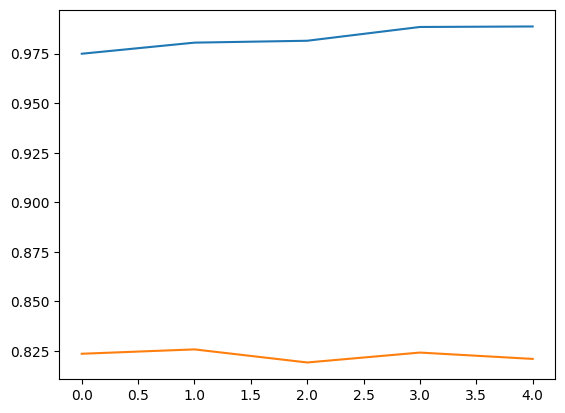

In [32]:
plt.plot(history2.history['accuracy'],label='accuracy')
plt.plot(history2.history['val_accuracy'],label='validation_accuracy')